In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller



sns.set(style="darkgrid")

In [4]:
df = pd.read_csv("../data/smart_aquarium_dataset_v6.1.csv")

df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

df.head()

,temperature,ph,tds,turbidity,ph_variance,tds_variance,temperature_variance,turbidity_variance,kh,computed_WQI,...,fish_stress_score,ground_truth_label,label_confidence,is_anomaly,raw_ph,raw_tds,raw_temperature,raw_turbidity,true_ph,true_tds
timestamp,,,,,,,,,,,,,,,,,,,,,
2026-01-01 00:00:00,24.2,7.01,150,2.1,0.000000,0.0000,0.000000,0.000000,6.0,100.0,...,1.45,NORMAL_STABLE,1.0,0,0.00,0.000000,0.0,0.0,7.00,150.0
2026-01-01 00:05:00,24.1,7.01,149,2.0,0.000149,2.0855,0.023798,0.016801,6.0,100.0,...,1.44,NORMAL_STABLE,1.0,0,7.01,148.942530,24.1,2.0,7.01,148.9
2026-01-01 00:10:00,24.0,7.01,149,2.2,0.000164,1.3643,0.013826,0.007498,6.0,100.0,...,1.44,NORMAL_STABLE,1.0,0,7.01,148.942878,24.0,2.2,7.01,148.9
2026-01-01 00:15:00,23.9,7.01,149,2.3,0.000557,1.1456,0.007367,0.030060,6.0,100.0,...,1.44,NORMAL_STABLE,1.0,0,7.01,148.943225,23.9,2.3,7.01,148.9
2026-01-01 00:20:00,23.7,7.01,149,2.6,0.000113,4.0042,0.015599,0.008473,6.0,100.0,...,1.44,NORMAL_STABLE,1.0,0,7.01,148.943572,23.7,2.6,7.01,148.9


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8640 entries, 2026-01-01 00:00:00 to 2026-01-30 23:55:00
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   temperature           8640 non-null   float64
 1   ph                    8640 non-null   float64
 2   tds                   8640 non-null   int64  
 3   turbidity             8640 non-null   float64
 4   ph_variance           8640 non-null   float64
 5   tds_variance          8640 non-null   float64
 6   temperature_variance  8640 non-null   float64
 7   turbidity_variance    8640 non-null   float64
 8   kh                    8640 non-null   float64
 9   computed_WQI          8640 non-null   float64
 10  maintenance_state     8640 non-null   object 
 11  dissolved_oxygen      8640 non-null   float64
 12  fish_stress_score     8640 non-null   float64
 13  ground_truth_label    8640 non-null   object 
 14  label_confidence      8640 non-null 

In [12]:
print("\nStatistical Summary:")
display(df.describe())


Statistical Summary:


,temperature,ph,tds,turbidity,ph_variance,tds_variance,temperature_variance,turbidity_variance,kh,computed_WQI,dissolved_oxygen,fish_stress_score,label_confidence,is_anomaly,raw_ph,raw_tds,raw_temperature,raw_turbidity,true_ph,true_tds
count,8640.00000,8640.000000,8640.000000,8640.000000,8640.000000,8640.000000,8640.000000,8640.000000,8640.000000,8640.000000,8640.000000,8640.000000,8640.000000,8640.000000,8633.000000,8634.000000,8630.000000,8632.000000,8640.000000,8640.000000
mean,24.82110,7.337763,260.951736,9.725579,0.001155,13.243148,0.051410,0.190016,4.112669,80.682922,6.950646,14.717740,0.898882,0.030556,7.340770,260.707349,24.792677,9.711816,7.324404,260.070764
std,1.43794,0.446363,64.194144,5.055714,0.000862,11.429299,0.039125,0.211243,1.110398,12.739382,0.955529,14.372063,0.245884,0.172120,0.503403,64.541329,1.666935,5.058164,0.438653,63.772824
min,22.40000,6.000000,148.000000,0.900000,0.000000,0.000000,0.000000,0.000000,0.000000,37.840000,3.740000,1.440000,0.047400,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,97.300000
25%,23.50000,7.090000,196.000000,6.000000,0.000490,4.420400,0.022113,0.053296,3.220000,70.350000,6.580000,2.947500,0.995325,0.000000,7.090000,195.766927,23.500000,6.000000,7.080000,195.875000
50%,24.80000,7.330000,279.000000,9.100000,0.000938,10.203200,0.041217,0.125393,4.100000,79.520000,7.120000,10.410000,1.000000,0.000000,7.330000,278.588919,24.800000,9.100000,7.320000,277.500000
75%,25.70000,7.680000,303.000000,11.900000,0.001588,18.619275,0.069946,0.245766,5.050000,92.555000,7.570000,23.682500,1.000000,0.000000,7.680000,302.529277,25.700000,11.800000,7.660000,301.400000
max,29.20000,8.100000,491.000000,25.000000,0.007693,123.911200,0.427995,2.610515,6.000000,100.000000,8.520000,78.120000,1.000000,1.000000,14.000000,490.910592,29.200000,25.000000,8.060000,488.900000


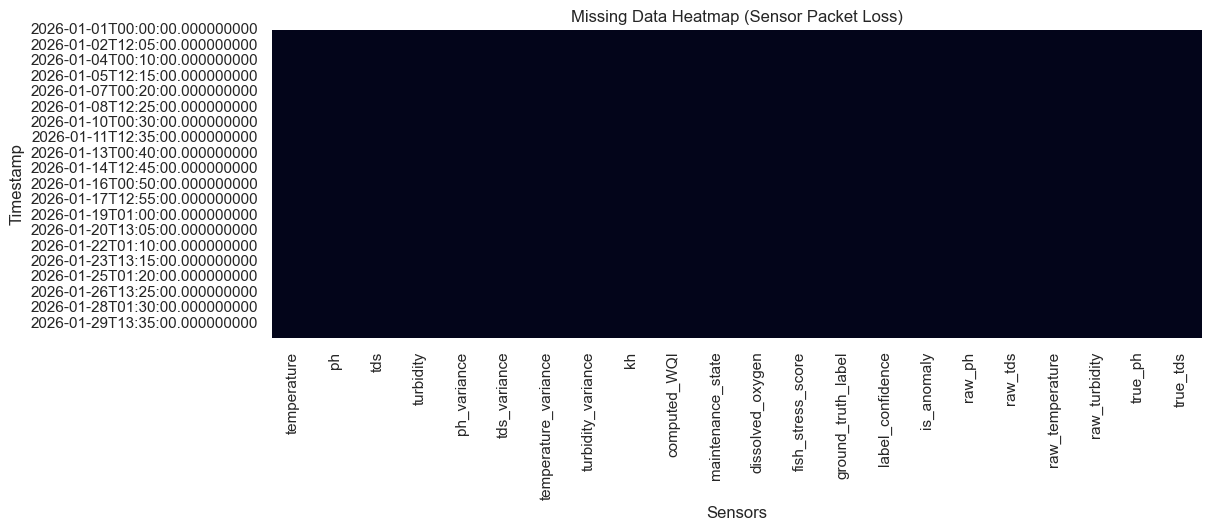

In [14]:
plt.figure(figsize=(12,4))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Data Heatmap (Sensor Packet Loss)")
plt.xlabel("Sensors")
plt.ylabel("Timestamp")
plt.show()

In [19]:
# Define the core sensor columns first to avoid NameError
sensor_cols = ['temperature', 'ph', 'tds', 'turbidity']

# Clean the dataset by filling gaps caused by sensor packet loss
# We focus on the core sensors used for the dashboard
df[sensor_cols] = df[sensor_cols].ffill()

print("Data Cleaning: Forward-fill applied. Dataset is now continuous for time-series analysis.")

Data Cleaning: Forward-fill applied. Dataset is now continuous for time-series analysis.


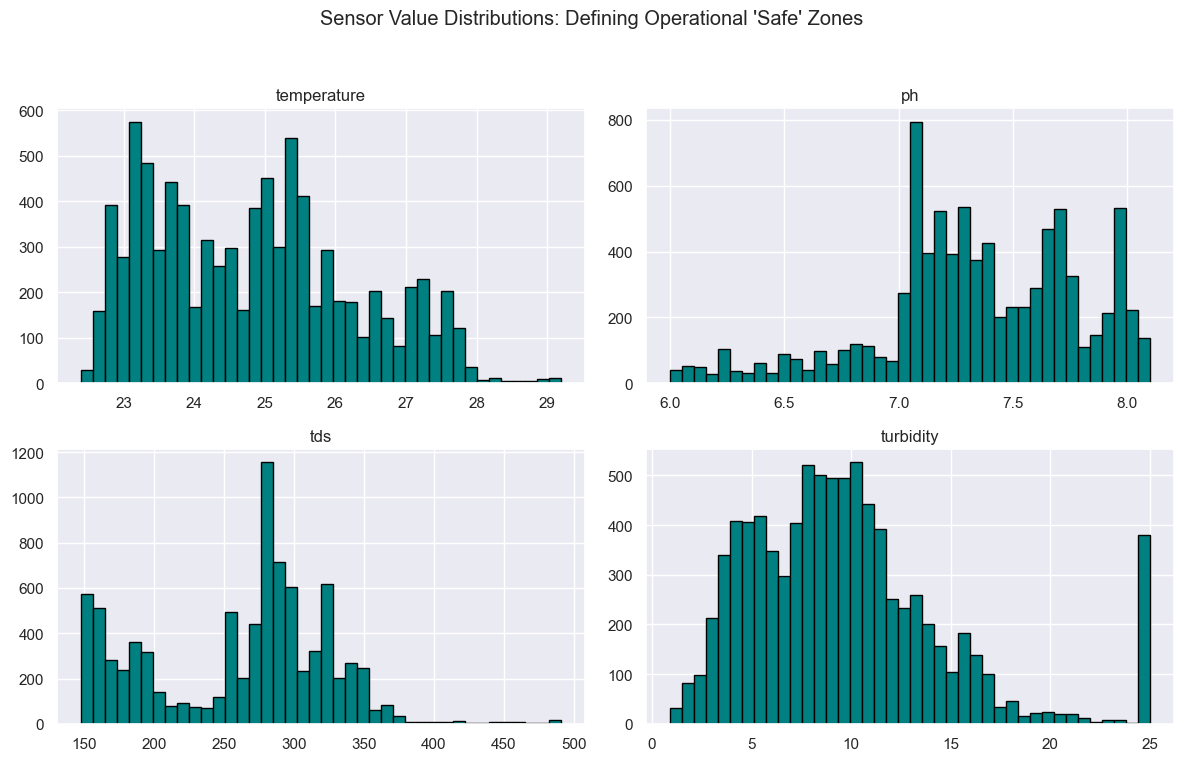

In [20]:
# Visualize distributions to define operational thresholds
df[sensor_cols].hist(figsize=(12, 8), bins=40, color='teal', edgecolor='black')
plt.suptitle("Sensor Value Distributions: Defining Operational 'Safe' Zones")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

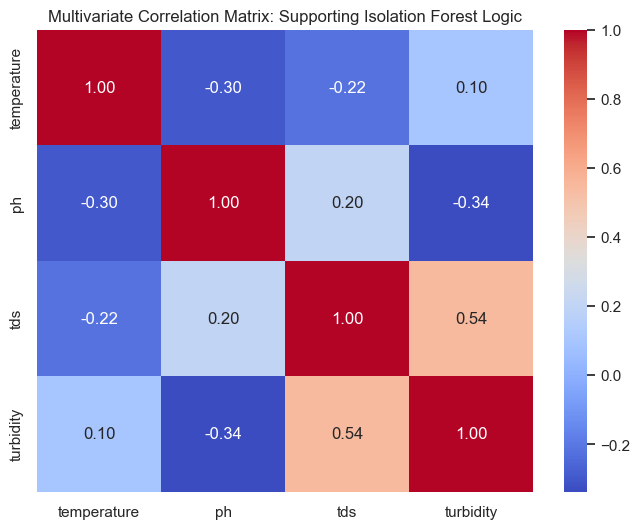

In [21]:
# Check how sensors relate to each other
plt.figure(figsize=(8, 6))
sns.heatmap(df[sensor_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Multivariate Correlation Matrix: Supporting Isolation Forest Logic")
plt.show()

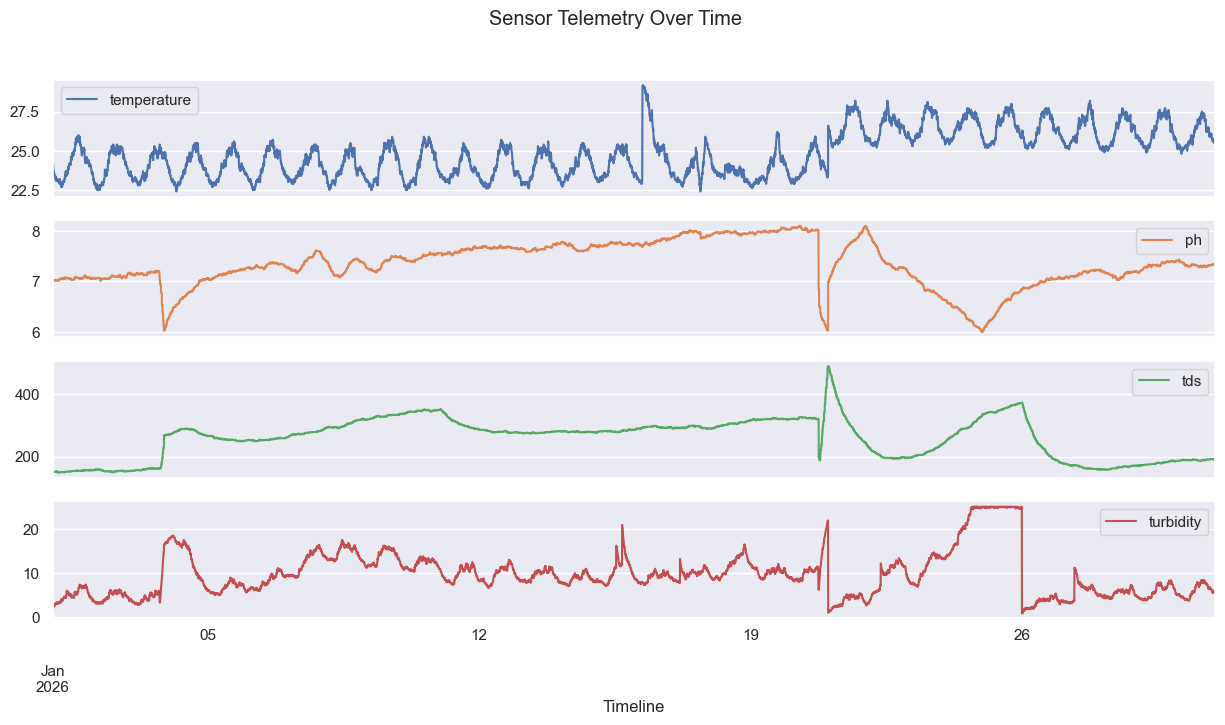

In [22]:
# Plotting sensors over time to observe environmental drift
df[sensor_cols].plot(figsize=(15, 7), subplots=True, title="Sensor Telemetry Over Time")
plt.xlabel("Timeline")
plt.show()

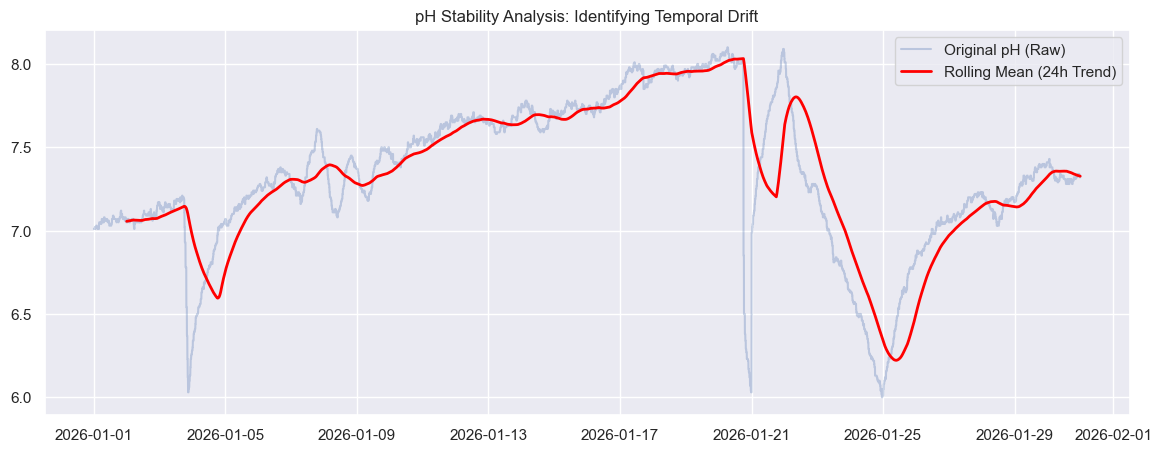

In [23]:
# 24-hour rolling mean to observe long-term trends
rolling_window = 288 
rolling_mean = df['ph'].rolling(window=rolling_window).mean()

plt.figure(figsize=(14, 5))
plt.plot(df['ph'], label='Original pH (Raw)', alpha=0.3)
plt.plot(rolling_mean, label='Rolling Mean (24h Trend)', color='red', linewidth=2)
plt.title("pH Stability Analysis: Identifying Temporal Drift")
plt.legend()
plt.show()

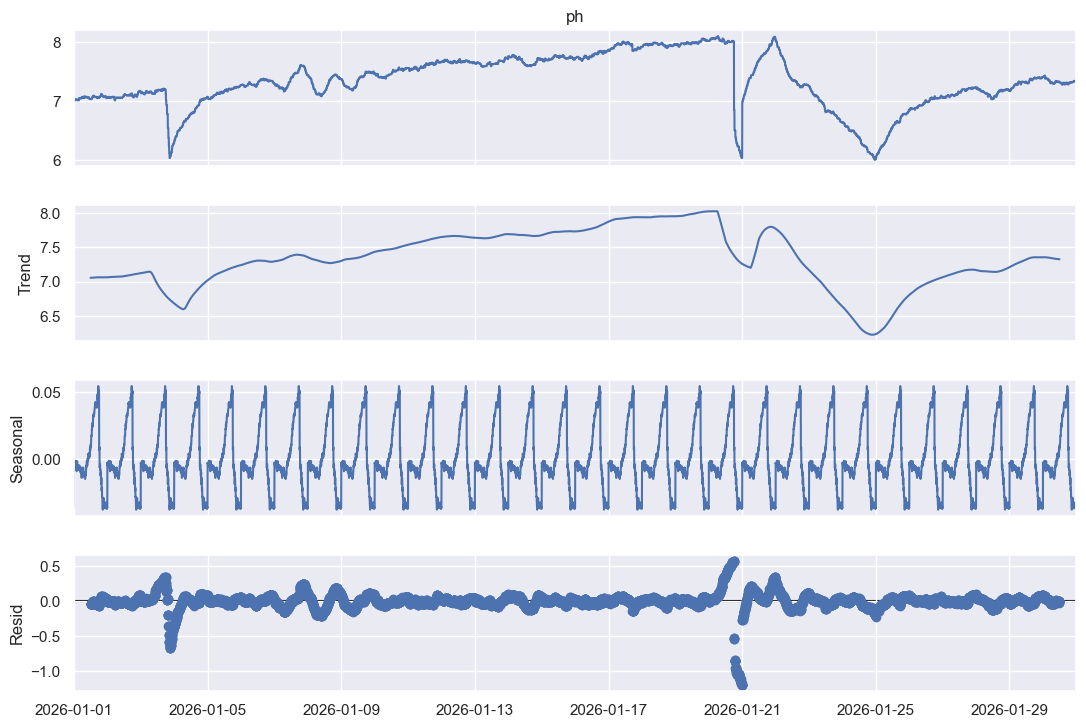

In [25]:
# Decompose pH to prove the 24-hour cycle exists
# Period=288 assumes 5-minute intervals
result = seasonal_decompose(df['ph'], model='additive', period=288)

fig = result.plot()
fig.set_size_inches(12, 8)
plt.show()

In [29]:
print('--- Augmented Dickey-Fuller Test ---')
result = adfuller(df['ph'])
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

if result[1] <= 0.05:
    print("Conclusion: Data is Stationary. ARIMA can forecast this trend accurately.")
else:
    print("Conclusion: Data is Non-Stationary. Differencing is needed.")

--- Augmented Dickey-Fuller Test ---
ADF Statistic: -2.8370919177034404
p-value: 0.05316766786482237
Conclusion: Data is Non-Stationary. Differencing is needed.


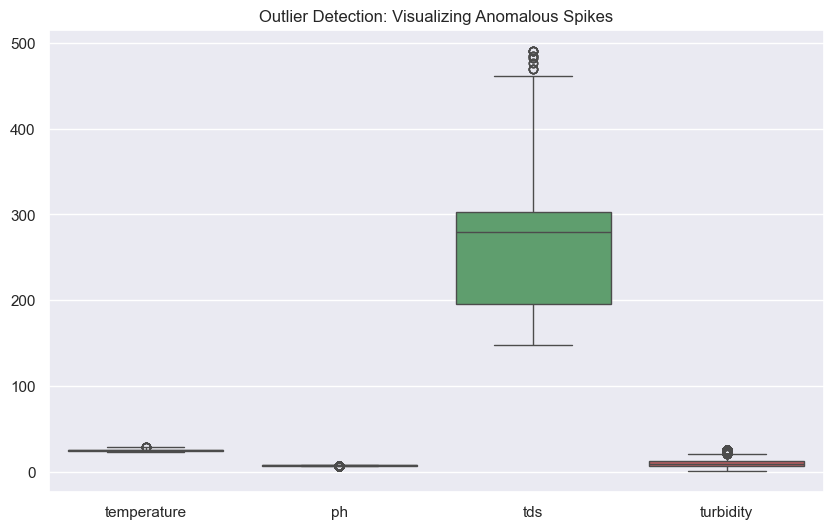

In [31]:
# Detecting extreme spikes (Sensor Noise vs Anomaly)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[sensor_cols])
plt.title("Outlier Detection: Visualizing Anomalous Spikes")
plt.show()

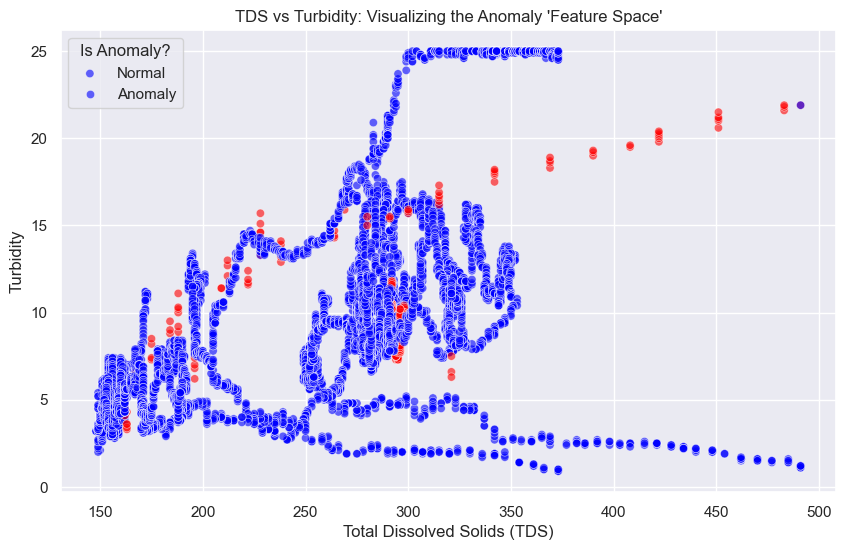

In [32]:
# Multivariate Relationship Analysis
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='tds', y='turbidity', hue='is_anomaly', palette={0: 'blue', 1: 'red'}, alpha=0.6)
plt.title("TDS vs Turbidity: Visualizing the Anomaly 'Feature Space'")
plt.xlabel("Total Dissolved Solids (TDS)")
plt.ylabel("Turbidity")
plt.legend(title="Is Anomaly?", labels=["Normal", "Anomaly"])
plt.show()

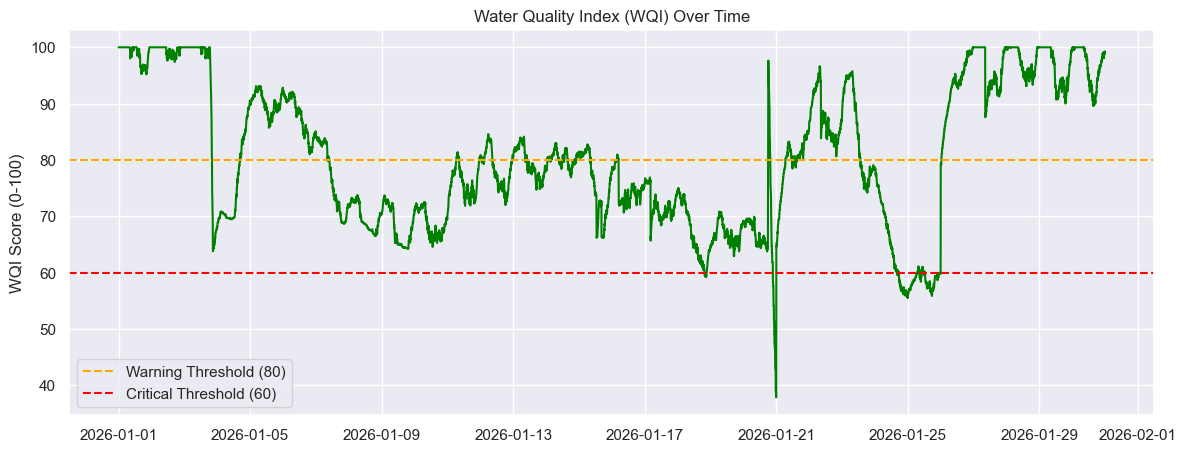

In [33]:
# Validating the Water Quality Index (WQI) Logic
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['computed_WQI'], color='green', linewidth=1.5)
plt.axhline(y=80, color='orange', linestyle='--', label='Warning Threshold (80)')
plt.axhline(y=60, color='red', linestyle='--', label='Critical Threshold (60)')
plt.title("Water Quality Index (WQI) Over Time")
plt.ylabel("WQI Score (0-100)")
plt.legend()
plt.show()